In [1]:
import os
import numpy as np
import pandas as pd
import sys
import json
import networkx as nx
import matplotlib.pyplot as plt
import math
from glob import glob
import os.path as op

# Add rpy2
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/Users/abry4213/miniforge3/envs/annie_env/lib/python3.10/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2EEBEE81-EBFD-3117-97B1-20AFEEB66792> /Users/abry4213/miniforge3/envs/annie_env/lib/python3.10/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


In [2]:
%%R 

suppressPackageStartupMessages({
    library(broom)
    library(cowplot)
    library(ggpubr)
    library(ggsignif)
    library(ggVennDiagram)
    library(glue)
    library(patchwork)
    library(rlist)
    library(see)
    library(tidyverse)
})


# Set cowplot theme
theme_set(theme_cowplot())

In addition: Warning messages:
1: package ‘broom’ was built under R version 4.4.3 
2: package ‘ggplot2’ was built under R version 4.4.3 
3: package ‘tidyr’ was built under R version 4.4.3 
4: package ‘readr’ was built under R version 4.4.3 


## How does each SPI perform in distinguishing (1) stimulus type and (2) relevance type, using averaged epochs compared across participants?

We can load the results from the logistic regression classification for (1) stimulus type and (2) relevance type):

In [3]:
# Define base_repo as one level up from current directory
base_repo = op.dirname(op.abspath(''))
plot_dir = f"{base_repo}/data_visualization/plots/"

# load pyspi SPI info
pyspi_SPI_info = pd.read_csv(f"{base_repo}/functional_connectivity_analysis/pyspi_SPI_info.csv")
functional_connectivity_measures_dir = f"{base_repo}/data/empirical/functional_connectivity_measures/"
classification_res_path = f"{base_repo}/data/empirical/classification_results/"

# Initialize list for pyspi results
all_pyspi_res_averaged_epochs_list = []

# Load classification res -- update to where you have stored your classification results

averaged_stimulus_type_LR_classification_res = pd.read_csv(f"{classification_res_path}/comparing_between_stimulus_types_Logistic_Regression_classification_results.csv")
averaged_relevance_type_LR_classification_res = pd.read_csv(f"{classification_res_path}/comparing_between_relevance_types_Logistic_Regression_classification_results.csv")
cross_task_LR_classification_res = pd.read_csv(f"{classification_res_path}/cross_task_Logistic_Regression_classification_results.csv")

# Add meta_ROI_pair column that combines the 'from' and 'to' meta-ROIs
averaged_stimulus_type_LR_classification_res["meta_ROI_pair"] = averaged_stimulus_type_LR_classification_res.meta_ROI_from + "__" + averaged_stimulus_type_LR_classification_res.meta_ROI_to
averaged_relevance_type_LR_classification_res["meta_ROI_pair"] = averaged_relevance_type_LR_classification_res.meta_ROI_from + "__" + averaged_relevance_type_LR_classification_res.meta_ROI_to
cross_task_LR_classification_res["meta_ROI_pair"] = cross_task_LR_classification_res.meta_ROI_from + "__" + cross_task_LR_classification_res.meta_ROI_to

## What is the overall distribution in SPI performance per classification task?

Before diving into any specific result, let's first see the distribution in performance across all SPIs per stimulus task classification problem (e.g., 'Face' vs. 'Object') by meta-ROI pair (e.g., 'GNWT' to 'CS')

[For supplementary figure]

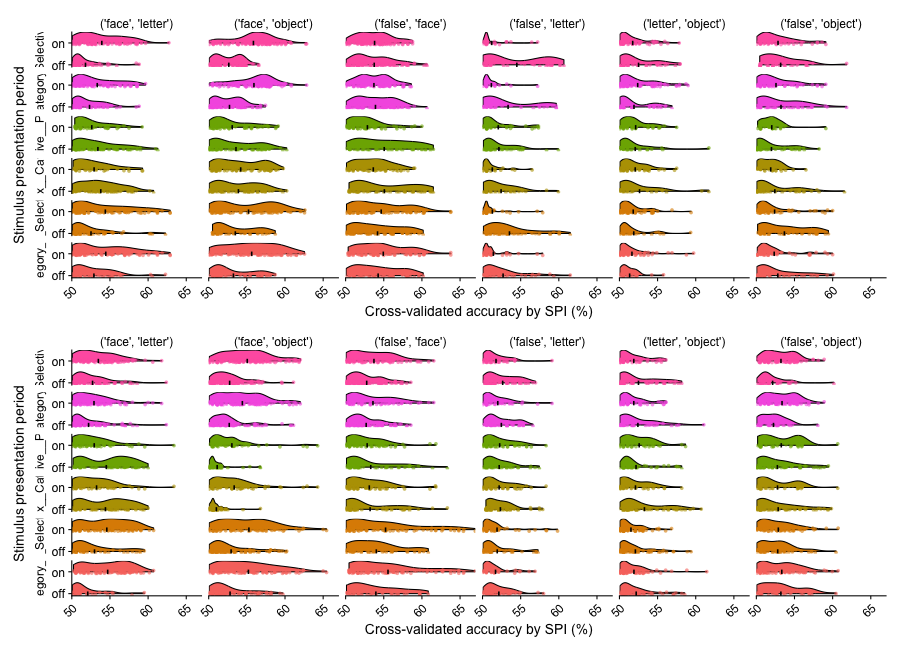

In [12]:
%%R -i averaged_stimulus_type_LR_classification_res,plot_dir -w 900 -h 650 

# Find limits for the y-axis common to both relevance types
y_max <- averaged_stimulus_type_LR_classification_res %>%
    filter(accuracy > 0.5, 
            stimulus_combo != "('face', 'non-face')",
            meta_ROI_pair %in% c("Category_Selective__V1_V2",
                                    "V1_V2__Category_Selective",
                                    "Category_Selective__Prefrontal_Cortex",
                                    "Prefrontal_Cortex__Category_Selective",
                                    "Category_Selective__IPS",
                                    "IPS__Category_Selective"
                                )) %>%
    ungroup() %>%
    filter(accuracy == max(accuracy)) %>% 
    distinct(accuracy) %>% 
    pull(accuracy)

plot_list <- list()

# Create raincloud plot visualization for all stimulus type classification results
for (this_rel in unique(averaged_stimulus_type_LR_classification_res$relevance_type)) {
    relevance_plot <- averaged_stimulus_type_LR_classification_res %>% 
        # Filter accuracy to >50% for visualization purposes
        filter(accuracy > 0.5, relevance_type==this_rel, meta_ROI_pair %in% c("Category_Selective__V1_V2",
                                                                                "V1_V2__Category_Selective",
                                                                                "Category_Selective__Prefrontal_Cortex",
                                                                                "Prefrontal_Cortex__Category_Selective",
                                                                                "Category_Selective__IPS",
                                                                                "IPS__Category_Selective"
                                                                            )) %>%
        mutate(accuracy = 100*accuracy) %>%
        rowwise() %>%
        # Want a specific order for the meta-ROI pair in the plot
        mutate(meta_ROI_pair = factor(meta_ROI_pair, levels = c("Category_Selective__V1_V2",
                                                                "V1_V2__Category_Selective",
                                                                "Category_Selective__Prefrontal_Cortex",
                                                                "Prefrontal_Cortex__Category_Selective",
                                                                "Category_Selective__IPS",
                                                                "IPS__Category_Selective"
                                                            )))  %>% 
        mutate(stimulus_combo = factor(stimulus_combo, levels = c("('face', 'letter')", "('face', 'object')",  
                                                                "('false', 'face')",  "('false', 'letter')",
                                                                "('letter', 'object')", "('false', 'object')"))) %>%
        filter(!is.na(stimulus_combo)) %>%
        ggplot(data=., mapping=aes(x=stimulus_presentation, y=accuracy, fill=meta_ROI_pair)) +
        # Create half violins colored by meta-ROI pair and stimulus presentation period
        geom_violinhalf(scale="width", color="black", position = position_dodge(width = 2), width=1)  +
        geom_point(aes(color = meta_ROI_pair), position = position_jitter(width = 0.075, height=0),
                                size = 1.75, alpha=0.6, stroke=0) +
        stat_summary(color="black", fun="mean", geom="crossbar", width=0.2, linewidth=0.3, 
                show.legend=FALSE, position = position_dodge(width=1.4)) +
        facet_grid(meta_ROI_pair ~ stimulus_combo, scales="free", switch="y") + 
        theme(legend.position = "bottom") +
        scale_x_discrete(expand = c(0, 0)) +
        scale_y_continuous(expand = c(0, 0), limits = c(50, 100*y_max), breaks=c(50, 55, 60, 65)) +
        scale_fill_manual(values = c(Category_Selective__V1_V2 = "#ff64b0",
                                     V1_V2__Category_Selective = "#f564e3",
                                     Category_Selective__Prefrontal_Cortex = "#7caf00",
                                     Prefrontal_Cortex__Category_Selective = "#b79f00",
                                     Category_Selective__IPS = "#de8c00",
                                     IPS__Category_Selective = "#f8766d")) +
        scale_color_manual(values = c(Category_Selective__V1_V2 = "#ff64b0",
                                     V1_V2__Category_Selective = "#f564e3",
                                     Category_Selective__Prefrontal_Cortex = "#7caf00",
                                     Prefrontal_Cortex__Category_Selective = "#b79f00",
                                     Category_Selective__IPS = "#de8c00",
                                     IPS__Category_Selective = "#f8766d")) +
        xlab("Stimulus presentation period") +
        ylab("Cross-validated accuracy by SPI (%)") +
        labs(fill="Stimulus Presentation", color="Stimulus Presentation") +
        theme(strip.background = element_blank(),
            strip.placement="outside",
            legend.position="none",
            panel.spacing = unit(0.5, "lines"),
            axis.text.x = element_text(angle=45, hjust=1)) +
        coord_flip()

    plot_list[[this_rel]] <- relevance_plot
}

wrap_plots(plotlist = plot_list, ncol = 1)
# ggsave(glue('{plot_dir}/inter_subject_classification/Stimulus_wise_classification_performance_by_meta_ROI_pair_across_relevance.svg'), width=9, height=11, units='in', dpi=300)


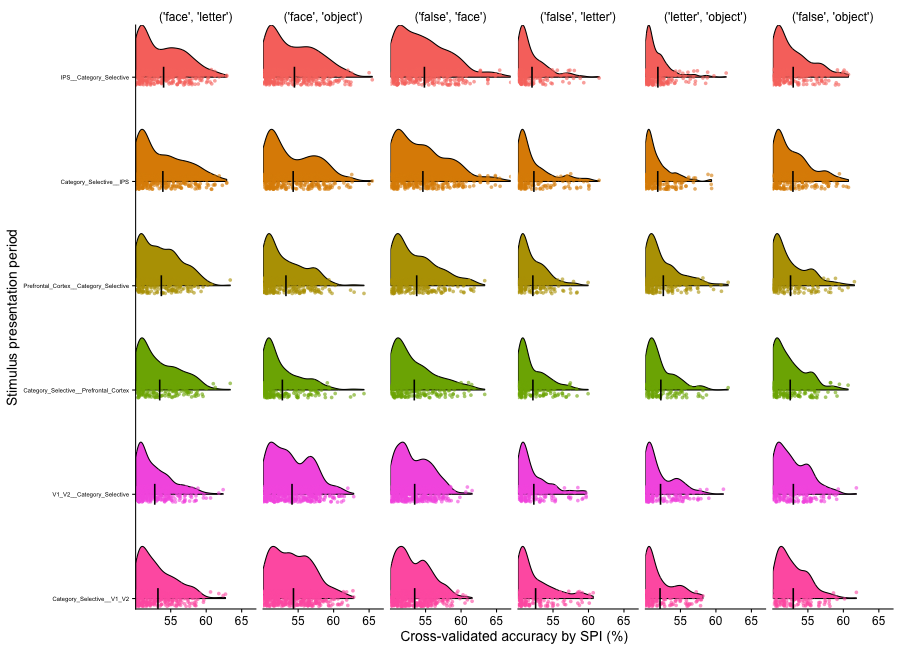

In [16]:
%%R -i averaged_stimulus_type_LR_classification_res,plot_dir -w 900 -h 650 


# Create raincloud plot visualization for all stimulus type classification results
averaged_stimulus_type_LR_classification_res %>% 
    # Filter accuracy to >50% for visualization purposes
    filter(accuracy > 0.5, meta_ROI_pair %in% c("Category_Selective__V1_V2",
                                                                            "V1_V2__Category_Selective",
                                                                            "Category_Selective__Prefrontal_Cortex",
                                                                            "Prefrontal_Cortex__Category_Selective",
                                                                            "Category_Selective__IPS",
                                                                            "IPS__Category_Selective"
                                                                        )) %>%
    mutate(accuracy = 100*accuracy) %>%
    rowwise() %>%
    # Want a specific order for the meta-ROI pair in the plot
    mutate(meta_ROI_pair = factor(meta_ROI_pair, levels = c("Category_Selective__V1_V2",
                                                            "V1_V2__Category_Selective",
                                                            "Category_Selective__Prefrontal_Cortex",
                                                            "Prefrontal_Cortex__Category_Selective",
                                                            "Category_Selective__IPS",
                                                            "IPS__Category_Selective"
                                                        )))  %>% 
    mutate(stimulus_combo = factor(stimulus_combo, levels = c("('face', 'letter')", "('face', 'object')",  
                                                            "('false', 'face')",  "('false', 'letter')",
                                                            "('letter', 'object')", "('false', 'object')"))) %>%
    filter(!is.na(stimulus_combo)) %>%
    ggplot(data=., mapping=aes(x=meta_ROI_pair, y=accuracy, fill=meta_ROI_pair)) +
    # Create half violins colored by meta-ROI pair and stimulus presentation period
    geom_violinhalf(scale="width", color="black", position = position_dodge(width = 2), width=1)  +
    geom_point(aes(color = meta_ROI_pair), position = position_jitter(width = 0.075, height=0),
                            size = 1.75, alpha=0.6, stroke=0) +
    stat_summary(color="black", fun="mean", geom="crossbar", width=0.2, linewidth=0.3, 
            show.legend=FALSE, position = position_dodge(width=1.4)) +
    facet_grid(. ~ stimulus_combo, scales="free", switch="y") + 
    theme(legend.position = "bottom") +
    scale_x_discrete(expand = c(0, 0)) +
    scale_y_continuous(expand = c(0, 0), breaks=c(50, 55, 60, 65)) +
    scale_fill_manual(values = c(Category_Selective__V1_V2 = "#ff64b0",
                                    V1_V2__Category_Selective = "#f564e3",
                                    Category_Selective__Prefrontal_Cortex = "#7caf00",
                                    Prefrontal_Cortex__Category_Selective = "#b79f00",
                                    Category_Selective__IPS = "#de8c00",
                                    IPS__Category_Selective = "#f8766d")) +
    scale_color_manual(values = c(Category_Selective__V1_V2 = "#ff64b0",
                                    V1_V2__Category_Selective = "#f564e3",
                                    Category_Selective__Prefrontal_Cortex = "#7caf00",
                                    Prefrontal_Cortex__Category_Selective = "#b79f00",
                                    Category_Selective__IPS = "#de8c00",
                                    IPS__Category_Selective = "#f8766d")) +
    xlab("Stimulus presentation period") +
    ylab("Cross-validated accuracy by SPI (%)") +
    labs(fill="Stimulus Presentation", color="Stimulus Presentation") +
    theme(strip.background = element_blank(),
        strip.placement="outside",
        legend.position="none",
        panel.spacing = unit(0.5, "lines"),
        axis.text.y = element_text(size=6)) +
    coord_flip()

# ggsave(glue('{plot_dir}/inter_subject_classification/Stimulus_wise_classification_performance_by_meta_ROI_pair_combined.svg'), width=8, height=4, units='in', dpi=300)


### How about cross-task distribution?

In [65]:
%%R -i cross_task_LR_classification_res,plot_dir -w 900 -h 650 

# Create raincloud plot visualization for all stimulus type classification results
for (cross_task_direction in unique(cross_task_LR_classification_res$cross_task_direction)) {
    cross_task_LR_classification_res %>% 
        # Filter accuracy to >50% for visualization purposes
        filter(accuracy > 0.5, cross_task_direction==cross_task_direction, meta_ROI_pair %in% c("Category_Selective__V1_V2",
                                                                                                "V1_V2__Category_Selective",
                                                                                                "Category_Selective__Prefrontal_Cortex",
                                                                                                "Prefrontal_Cortex__Category_Selective",
                                                                                                "Category_Selective__IPS",
                                                                                                "IPS__Category_Selective")) %>%
        mutate(accuracy = 100*accuracy) %>%
        rowwise() %>%
        # Want a specific order for the meta-ROI pair in the plot
        mutate(meta_ROI_pair = factor(meta_ROI_pair, levels = c("Category_Selective__V1_V2",
                                                                "V1_V2__Category_Selective",
                                                                "Category_Selective__Prefrontal_Cortex",
                                                                "Prefrontal_Cortex__Category_Selective",
                                                                "Category_Selective__IPS",
                                                                "IPS__Category_Selective"
                                                            )))  %>% 
        mutate(stimulus_combo = factor(stimulus_combo, levels = c("('face', 'letter')", "('face', 'object')",  
                                                                "('false', 'face')",  "('false', 'letter')",
                                                                "('letter', 'object')", "('false', 'object')"))) %>%
        filter(!is.na(stimulus_combo)) %>%
        ggplot(data=., mapping=aes(x=stimulus_presentation, y=accuracy, fill=meta_ROI_pair)) +
        # Create half violins colored by meta-ROI pair and stimulus presentation period
        geom_violinhalf(scale="width", color="black", position = position_dodge(width = 2), width=1)  +
        geom_point(aes(color = meta_ROI_pair), position = position_jitter(width = 0.075, height=0),
                                size = 1.75, alpha=0.6, stroke=0) +
        stat_summary(color="black", fun="mean", geom="crossbar", width=0.2, linewidth=0.3, 
                show.legend=FALSE, position = position_dodge(width=1.4)) +
        facet_grid(meta_ROI_pair ~ stimulus_combo, scales="free", switch="y") + 
        theme(legend.position = "bottom") +
        scale_x_discrete(expand = c(0, 0)) +
        xlab("Stimulus presentation period") +
        ylab("Cross-validated accuracy by SPI (%)") +
        labs(fill="Stimulus Presentation", color="Stimulus Presentation") +
        theme(strip.background = element_blank(),
            strip.placement="outside",
            legend.position="none",
            panel.spacing = unit(0.5, "lines"),
            axis.text.x = element_text(angle=45, hjust=1)) +
        coord_flip()

    # ggsave(glue('{plot_dir}/plots/inter_subject_classification/Stimulus_wise_classification_performance_by_meta_ROI_pair_{cross_task_direction}.svg'), width=10, height=12, units='in', dpi=300)
}

## Examine the top-performing SPI for each ROI pair, zooming in on the top 4

R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: Removed 34 rows containing missing values or values outside the scale range
(`geom_text()`). 



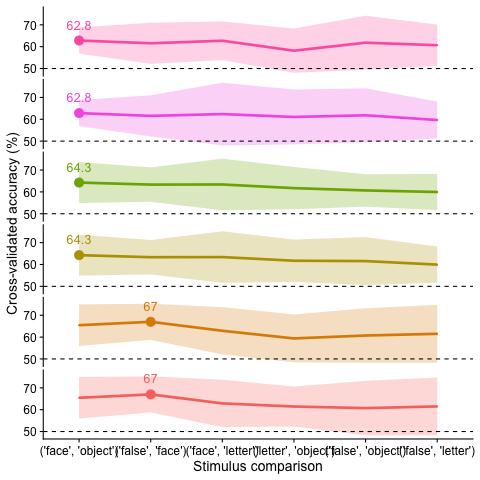

In [16]:
%%R -i averaged_stimulus_type_LR_classification_res,plot_dir -o top_res

# Line plot showing the maximum cross-validated accuracy for each 
# stimulus comparison (x-axis) and meta-ROI pair (colored lines)
top_res <- averaged_stimulus_type_LR_classification_res %>% 
    group_by(meta_ROI_pair, stimulus_combo) %>% 
    filter(meta_ROI_pair %in% c("Category_Selective__V1_V2",
                                "V1_V2__Category_Selective",
                                "Category_Selective__Prefrontal_Cortex",
                                "Prefrontal_Cortex__Category_Selective",
                                "Category_Selective__IPS",
                                "IPS__Category_Selective")) %>%
    # Want a specific order for the meta-ROI pair in the plot
    mutate(meta_ROI_pair = factor(meta_ROI_pair, levels = c("Category_Selective__V1_V2",
                                                            "V1_V2__Category_Selective",
                                                            "Category_Selective__Prefrontal_Cortex",
                                                            "Prefrontal_Cortex__Category_Selective",
                                                            "Category_Selective__IPS",
                                                            "IPS__Category_Selective")),
            stimulus_combo = str_replace_all(stimulus_combo, "False", "false"))  %>% 
    # Find maximum accuracy
    filter(accuracy==max(accuracy,na.rm=T)) %>%
    ungroup() %>%
    mutate(accuracy=100*accuracy,
           accuracy_SD=100*accuracy_SD,
           stimulus_combo = factor(stimulus_combo, 
                                   levels = c("('face', 'object')",  
                                              "('false', 'face')",
                                              "('face', 'letter')", 
                                              "('letter', 'object')", 
                                              "('false', 'object')", 
                                              "('false', 'letter')"))) %>% 
    filter(!is.na(stimulus_combo)) %>%
    group_by(meta_ROI_pair) %>%
    mutate(is_max = ifelse(accuracy==max(accuracy,na.rm=T), "Max", "Not Max"),
           max_label = ifelse(is_max=="Max", round(accuracy, 1), NA_real_)) 
                                              
top_res %>%
    ggplot(data=., mapping=aes(x=stimulus_combo, y=accuracy, color=meta_ROI_pair, group=meta_ROI_pair)) +
    geom_ribbon(aes(ymin=accuracy-accuracy_SD, ymax=accuracy+accuracy_SD, fill=meta_ROI_pair), alpha=0.25, color=NA) +
    geom_line(linewidth=1.25) +
    geom_point(aes(size=is_max)) + 
    scale_size_manual(values=c("Not Max" = 0, "Max" = 4)) +
    geom_text(aes(label=max_label), hjust=0.5, vjust=-1.25, size=4.5) +
    xlab("Stimulus comparison") +
    ylab("Cross-validated accuracy (%)") +
    # Set y-axis breaks to only 60 and 65
    # scale_y_continuous(breaks=c(60,65)) +
    scale_x_discrete(expand = c(0.1, 0)) +
    geom_hline(yintercept=50, linetype="dashed", color = "black") +
     scale_fill_manual(values = c(Category_Selective__V1_V2 = "#ff64b0",
                                     V1_V2__Category_Selective = "#f564e3",
                                     Category_Selective__Prefrontal_Cortex = "#7caf00",
                                     Prefrontal_Cortex__Category_Selective = "#b79f00",
                                     Category_Selective__IPS = "#de8c00",
                                     IPS__Category_Selective = "#f8766d")) +
        scale_color_manual(values = c(Category_Selective__V1_V2 = "#ff64b0",
                                     V1_V2__Category_Selective = "#f564e3",
                                     Category_Selective__Prefrontal_Cortex = "#7caf00",
                                     Prefrontal_Cortex__Category_Selective = "#b79f00",
                                     Category_Selective__IPS = "#de8c00",
                                     IPS__Category_Selective = "#f8766d")) +
    facet_grid(meta_ROI_pair ~ ., scales="free_x") +
    theme(legend.position="none", strip.background = element_blank(),
          strip.placement="outside", strip.text = element_blank(),
          panel.spacing = unit(0.25, "lines"))
          
# ggsave('{plot_dir}/inter_subject_classification/Max_performance_for_each_stim_combo_by_meta_ROI_pair.svg', width=4.5, height=9, units='in', dpi=300)

## Euler diagrams for SPIs greater than 60% accuracy

In [17]:
# Filter to accuracy > 60%
face_non_face = "('face', 'non-face')"
averaged_stimulus_type_LR_classification_res_above_60 = averaged_stimulus_type_LR_classification_res.query("accuracy >= 0.6 & stimulus_combo != @face_non_face & meta_ROI_pair in ['Category_Selective__V1_V2', 'V1_V2__Category_Selective', 'Category_Selective__Prefrontal_Cortex', 'Prefrontal_Cortex__Category_Selective', 'Category_Selective__IPS', 'IPS__Category_Selective']")

# For each ROI (from or to, doesn't matter), find all of the unique SPIs that have accuracy > 60%
unique_SPIs_from = averaged_stimulus_type_LR_classification_res_above_60.groupby("meta_ROI_from").SPI.unique().reset_index()
unique_SPIs_to = averaged_stimulus_type_LR_classification_res_above_60.groupby("meta_ROI_to").SPI.unique().reset_index()

# Convert from list-column to long format
unique_SPIs_from_long = unique_SPIs_from.explode("SPI")
unique_SPIs_to_long = unique_SPIs_to.explode("SPI")

/Users/abry4213/miniforge3/envs/annie_env/lib/python3.10/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '


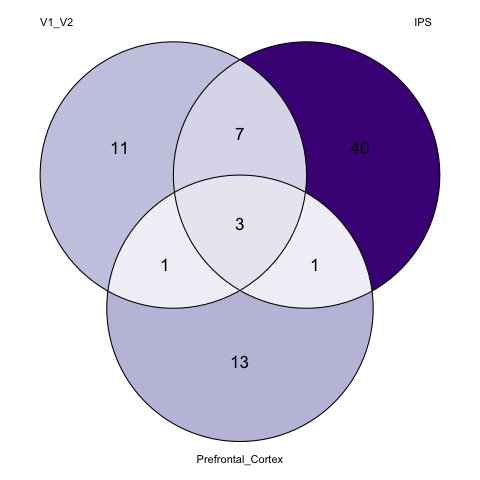

In [18]:
%%R -i unique_SPIs_to_long,plot_dir

SPIs_to_venn <- split(unique_SPIs_to_long, unique_SPIs_to_long$meta_ROI_to)
SPIs_to_venn <- lapply(SPIs_to_venn, function(x) x %>% pull(SPI))
SPIs_to_venn <- SPIs_to_venn[c("V1_V2", "IPS", "Prefrontal_Cortex")]

venn_to <- Venn(SPIs_to_venn)
data_to <- process_data(venn_to, shape_id = "301f")

ggplot() +
  # 1. region count layer
  geom_polygon(aes(X, Y, fill = count, group = id), 
          data = venn_regionedge(data_to)) +
  # 2. set edge layer
  geom_path(aes(X, Y, group = id), 
          data = venn_setedge(data_to), 
          show.legend = FALSE) +
  # 3. set label layer
  geom_text(aes(X, Y, label = name), 
               data = venn_setlabel(data_to)) +
  # 4. region label layer
  geom_text(aes(X, Y, label = count), size=6, 
                data = venn_regionlabel(data_to)) +
  coord_equal() +
  theme_void() +
  scale_fill_distiller(palette = "Purples", direction = 1) +
  labs(fill="# SPIs") +
  theme(legend.position="none")

# ggsave(glue("{plot_dir}/inter_subject_classification/Top_SPIs_from_CS_Euler.svg"), width=4.5, height=4.5, units='in', dpi=300)

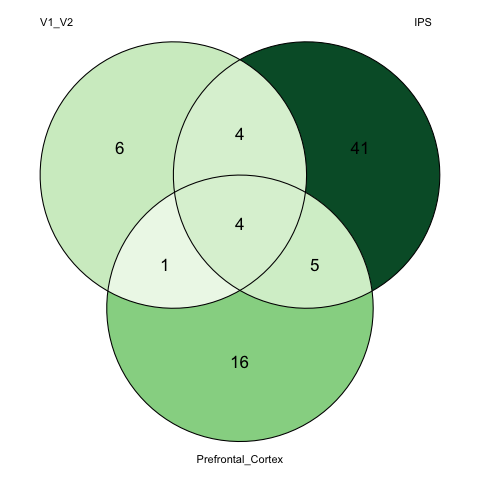

In [19]:
%%R -i unique_SPIs_from_long,plot_dir

SPIs_from_venn <- split(unique_SPIs_from_long, unique_SPIs_from_long$meta_ROI_from)
SPIs_from_venn <- lapply(SPIs_from_venn, function(x) x %>% pull(SPI))
SPIs_from_venn <- SPIs_from_venn[c("V1_V2", "IPS", "Prefrontal_Cortex")]

venn_from <- Venn(SPIs_from_venn)
data_from <- process_data(venn_from, shape_id = "301f")

ggplot() +
  # 1. region count layer
  geom_polygon(aes(X, Y, fill = count, group = id), 
          data = venn_regionedge(data_from)) +
  # 2. set edge layer
  geom_path(aes(X, Y, group = id), 
          data = venn_setedge(data_from), 
          show.legend = FALSE) +
  # 3. set label layer
  geom_text(aes(X, Y, label = name), 
               data = venn_setlabel(data_from)) +
  # 4. region label layer
  geom_text(aes(X, Y, label = count), size=6,
                data = venn_regionlabel(data_from)) +
  coord_equal() +
  theme_void() +
  scale_fill_distiller(palette = "Greens", direction = 1) +
  theme(legend.position="none")
  
# ggsave(glue("{plot_dir}/inter_subject_classification/Top_SPIs_to_CS_Euler.svg"), width=4.5, height=4.5, units='in', dpi=300)

### Which SPI is at the center of both Euler diagrams?

In [20]:
%%R -i unique_SPIs_from_long,unique_SPIs_to_long

SPI_all_four_from <- unique_SPIs_from_long %>% 
    filter(meta_ROI_from %in% c("V1_V2", "IPS", "Prefrontal_Cortex")) %>%
    group_by(SPI) %>% 
    count() %>% 
    ungroup() %>% 
    filter(n == 3)

SPI_all_four_to <- unique_SPIs_to_long %>%
    filter(meta_ROI_to %in% c("V1_V2", "IPS", "Prefrontal_Cortex")) %>%
    group_by(SPI) %>% 
    count() %>% 
    ungroup() %>% 
    filter(n == 3)

print(glue("SPIs that are present in all pathways to Category-Selective: {SPI_all_four_from$SPI}"))
print(glue("SPIs that are present in all pathways from Category-Selective: {SPI_all_four_to$SPI}"))

SPIs that are present in all pathways to Category-Selective: bary-sq_dtw_max
SPIs that are present in all pathways to Category-Selective: bary-sq_sgddtw_max
SPIs that are present in all pathways to Category-Selective: bary-sq_softdtw_max
SPIs that are present in all pathways to Category-Selective: reci
SPIs that are present in all pathways from Category-Selective: bary-sq_dtw_max
SPIs that are present in all pathways from Category-Selective: bary-sq_sgddtw_max
SPIs that are present in all pathways from Category-Selective: bary-sq_softdtw_max


In [21]:
from_CS_top_SPIs = averaged_stimulus_type_LR_classification_res_above_60.query("meta_ROI_from=='Category_Selective'")[['SPI', 'meta_ROI_to']].drop_duplicates().merge(pyspi_SPI_info, how='left', on='SPI')
to_CS_top_SPIs = averaged_stimulus_type_LR_classification_res_above_60.query("meta_ROI_to=='Category_Selective'")[['SPI', 'meta_ROI_from']].drop_duplicates().merge(pyspi_SPI_info, how='left', on='SPI')

## What type(s) of SPIs perform the best (1) by meta-ROI pair and (2) by stimulus type comparison?

Since each SPI belongs to a particular literature category (e.g., 'spectral' or 'information theory'), we can compare the composition of the top-performing (>62% accuracy) SPIs in each context -- first, by meta-ROI pair:

In [22]:
# Merge SPI info with results
unique_SPIs_from_long = unique_SPIs_from_long.merge(pyspi_SPI_info, how='left', on='SPI')
unique_SPIs_to_long = unique_SPIs_to_long.merge(pyspi_SPI_info, how='left', on='SPI')

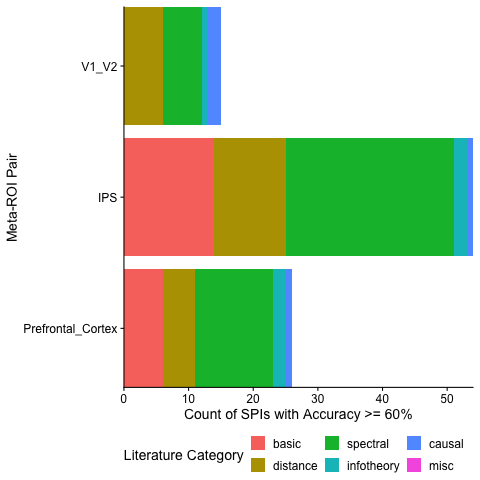

In [23]:
%%R -i unique_SPIs_from_long,plot_dir

# A) By meta-ROI pair, stacked bar chart showing the relative composition of SPIs with accuracy > 65%
unique_SPIs_from_long %>% 
    filter(meta_ROI_from %in% c("V1_V2", "IPS", "Prefrontal_Cortex")) %>%
    mutate(Literature_category = factor(Literature_category, levels = c("basic", "distance", "spectral", 
                                                                        "infotheory", "causal", "misc")),
            meta_ROI_from = factor(meta_ROI_from, levels = rev(c("V1_V2", "IPS", "Prefrontal_Cortex")))) %>%
    ggplot(data=., mapping=aes(x=meta_ROI_from, fill=Literature_category)) +
    # Reverse the order in which the bars are stacked
    geom_bar(show.legend = TRUE, position = position_stack(reverse = TRUE)) +
    coord_flip() +
    xlab("Meta-ROI Pair") +
    scale_fill_discrete(drop=FALSE) +
    # Keep all factor levels in legend
    guides(fill=guide_legend(title="Literature Category")) +
    scale_y_continuous(expand=c(0,0)) +
    scale_x_discrete(expand=c(0,0)) +
    ylab("Count of SPIs with Accuracy >= 60%") +
    theme(legend.position = "bottom")
# ggsave(glue('{plot_dir}/inter_subject_classification/ROI_to_CS_top_SPI_categories.svg'), width=5, height=3.5, units='in', dpi=300)

Joining with `by = join_by(SPI, Directionality, Literature_category, Module)`


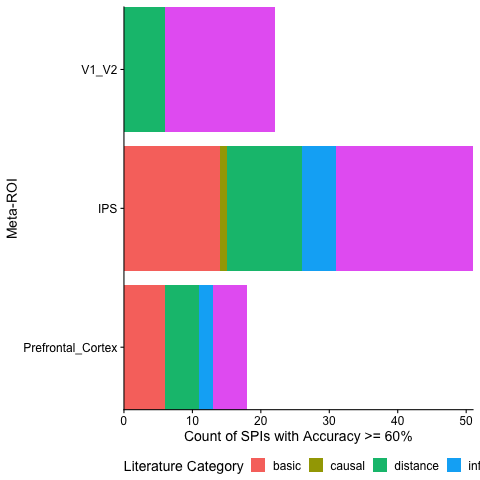

In [25]:
%%R -i unique_SPIs_to_long,pyspi_SPI_info,plot_dir

# A) By meta-ROI pair, stacked bar chart showing the relative composition of SPIs with accuracy > 65%
unique_SPIs_to_long %>% 
    left_join(., pyspi_SPI_info %>% mutate(Literature_category = factor(Literature_category,
                                                                        levels = c("basic", "distance", "spectral", 
                                                                                   "infotheory", "causal", "misc")))) %>% 
        mutate(meta_ROI_to = factor(meta_ROI_to, levels = rev(c("Category_Selective", "V1_V2", "IPS", "Prefrontal_Cortex")))) %>%
    filter(meta_ROI_to %in% c("V1_V2", "IPS", "Prefrontal_Cortex")) %>%
    ggplot(data=., mapping=aes(x=meta_ROI_to, fill=Literature_category)) +
    # Reverse the order in which the bars are stacked
    geom_bar(show.legend = TRUE, position = position_stack(reverse = TRUE)) +
    coord_flip() +
    xlab("Meta-ROI") +
    scale_fill_discrete(drop=FALSE) +
    # Keep all factor levels in legend
    guides(fill=guide_legend(title="Literature Category")) +
    scale_y_continuous(expand=c(0,0)) +
    scale_x_discrete(expand=c(0,0)) +
    ylab("Count of SPIs with Accuracy >= 60%") +
    theme(legend.position = "bottom")
# ggsave('{plot_dir}/inter_subject_classification/ROI_from_CS_top_SPI_categories.svg', width=5, height=3.5, units='in', dpi=300)

## What is the max performance by SPI across all analyses?

Joining with `by = join_by(SPI)`
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: Removed 88 rows containing missing values or values outside the scale range
(`geom_text()`). 



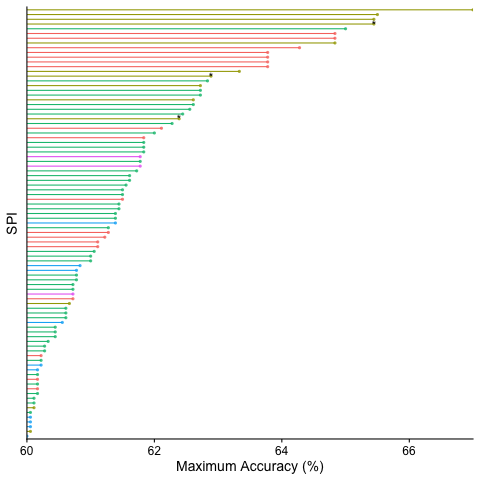

In [27]:
%%R -i averaged_stimulus_type_LR_classification_res,pyspi_SPI_info,plot_dir

averaged_stimulus_type_LR_classification_res %>% 
    group_by(SPI) %>% 
    filter(accuracy==max(accuracy, na.rm=T)) %>%
    ungroup() %>% 
    distinct(SPI, accuracy) %>% 
    filter(accuracy > 0.6) %>% 
    left_join(., pyspi_SPI_info) %>% 
    mutate(SPI = fct_reorder(SPI, accuracy, .desc=F),
           Literature_category = factor(Literature_category, 
                                        levels = c("basic", "distance", "spectral", 
                                        "infotheory", "causal", "misc")),
           SPI_label = ifelse(str_detect(SPI, "bary-sq_.*_max"), "*", NA_character_)) %>%
    ggplot(data=., mapping=aes(x=SPI, y=100*accuracy)) +
    geom_point(aes(color=Literature_category), alpha=0.8, stroke=0) +
    # Add a line from the point to the x-axis
    geom_segment(aes(xend=SPI, yend=60, color=Literature_category)) +
    geom_line() +
    geom_text(aes(label=SPI_label), size=4) +
    ylab("Maximum Accuracy (%)") +
    coord_flip() +
    scale_y_continuous(expand=c(0,0)) +
    theme(axis.text.y = element_blank(),
          axis.ticks.y = element_blank(),
          legend.position="none")
# ggsave(glue('{plot_dir}/inter_subject_classification/Max_classification_performance_by_SPI_category.svg'), width=3, height=8, units='in', dpi=300)

Joining with `by = join_by(SPI)`
`summarise()` has grouped output by 'SPI', 'Literature_category'. You can
override using the `.groups` argument.


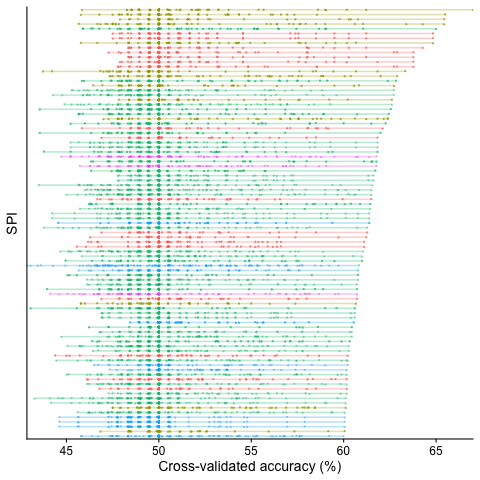

In [33]:
%%R -i averaged_stimulus_type_LR_classification_res,pyspi_SPI_info,plot_dir -o accuracy_above_60

accuracy_above_60 <- averaged_stimulus_type_LR_classification_res %>% 
    group_by(SPI) %>%
    filter(max(accuracy) > 0.6) %>% 
    left_join(., pyspi_SPI_info) %>% 
    ungroup() %>%
    mutate(SPI = fct_reorder(SPI, accuracy, .fun='max', .desc=F),
           accuracy=100*accuracy,
           Literature_category = factor(Literature_category, 
                                        levels = c("basic", "distance", "spectral", 
                                        "infotheory", "causal", "misc")),
           SPI_label = ifelse(str_detect(SPI, "bary-sq_.*_max"), "*", NA_character_)) 

accuracy_above_60 %>% 
    group_by(SPI, Literature_category, SPI_label) %>% 
    summarise(acc_min = min(accuracy), acc_max = max(accuracy)) %>%
    ggplot(data=., mapping=aes(x=SPI)) +
    geom_segment(aes(x=SPI, xend=SPI, y=acc_min, yend=acc_max, 
                     color=Literature_category), linewidth=0.75, alpha=0.3) +
    geom_point(data=accuracy_above_60,
               aes(color=Literature_category, y=accuracy),
               position = position_jitter(width = 0.1, height=0), 
               size = 1, alpha=0.5, stroke=0) +
    coord_flip()+
    scale_y_continuous(expand=c(0,0)) +
    ylab("Cross-validated accuracy (%)") +
    theme(axis.text.y = element_blank(),
          axis.ticks.y = element_blank(),
          legend.position="none")
# ggsave(glue('{plot_dir}/inter_subject_classification/Max_classification_performance_by_SPI_category.svg'), width=3, height=7, units='in', dpi=300)

# Task relevance analysis

`summarise()` has grouped output by 'SPI', 'meta_ROI_from', 'meta_ROI_to',
'meta_ROI_pair'. You can override using the `.groups` argument.


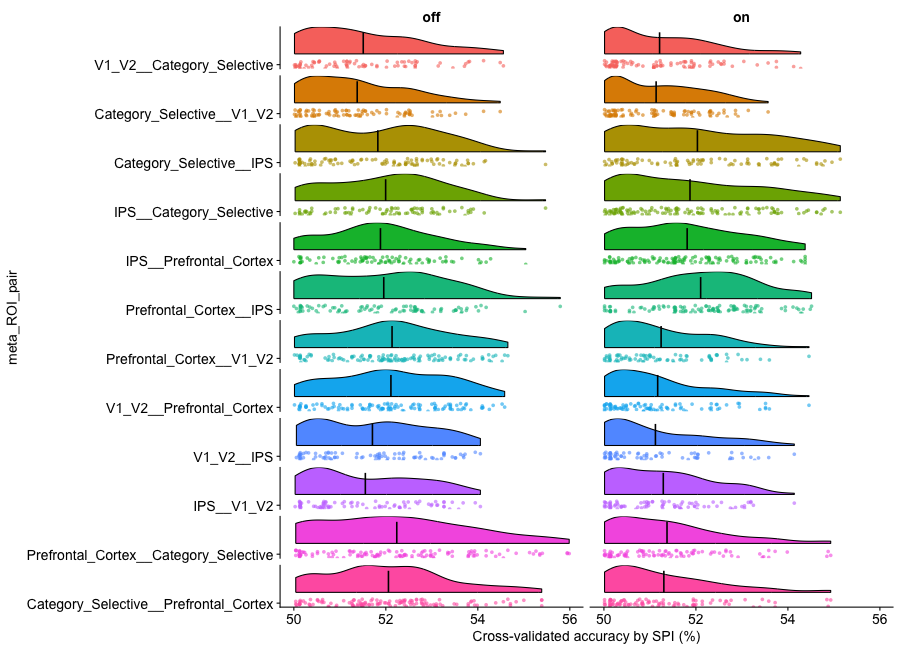

In [10]:
%%R -i averaged_relevance_type_LR_classification_res,plot_dir -w 900 -h 650 

averaged_relevance_type_LR_classification_res %>% 
    group_by(SPI, meta_ROI_from, meta_ROI_to, meta_ROI_pair, stimulus_presentation) %>%
    summarise(accuracy = mean(accuracy)) %>%
    # Filter accuracy to >50% for visualization purposes
    filter(accuracy > 0.5) %>%
    mutate(accuracy = 100*accuracy) %>%
    rowwise() %>%
    # Want a specific order for the meta-ROI pair in the plot
    mutate(meta_ROI_pair = factor(meta_ROI_pair, levels = c("V1_V2__Category_Selective",
                                                    "Category_Selective__V1_V2",
                                                    "Category_Selective__IPS",
                                                    "IPS__Category_Selective",
                                                    "IPS__Prefrontal_Cortex",
                                                    "Prefrontal_Cortex__IPS",
                                                    "Prefrontal_Cortex__V1_V2",
                                                    "V1_V2__Prefrontal_Cortex",
                                                    "V1_V2__IPS",
                                                    "IPS__V1_V2",
                                                    "Prefrontal_Cortex__Category_Selective",
                                                    "Category_Selective__Prefrontal_Cortex"))) %>%
    ggplot(data=., mapping=aes(x=meta_ROI_pair, y=accuracy, fill=meta_ROI_pair)) +
    # Create half violins colored by meta-ROI pair and stimulus presentation period
    geom_violinhalf(scale="width", color="black", position = position_nudge(x=0.2), width=1)  +
    geom_point(aes(color = meta_ROI_pair), position = position_jitter(width = 0.075, height=0),
                            size = 1.75, alpha=0.6, stroke=0) +
    stat_summary(color="black", fun="mean", geom="crossbar", width=0.4, linewidth=0.3, 
            show.legend=FALSE, position = position_nudge(x=0.4)) +
    facet_grid(meta_ROI_pair ~ stimulus_presentation, scales="free_y", switch="y") + 
    theme(legend.position = "bottom") +
    scale_x_discrete(expand = c(0, 0)) +
    ylab("Cross-validated accuracy by SPI (%)") +
    labs(fill="Stimulus Presentation", color="Stimulus Presentation") +
    theme(strip.background = element_blank(),
        strip.placement="outside",
        legend.position="none",
        panel.spacing = unit(0.5, "lines"),
        strip.text.y = element_blank(),
        strip.text.x = element_text(size=14, face="bold"),
        axis.text = element_text(size=14)) +
    coord_flip()

# ggsave(glue('{plot_dir}/inter_subject_classification/Relevance_type_classification_performance_by_meta_ROI_pair.svg'), width=8, height=8, units='in', dpi=300)

## Cross-task classification

`summarise()` has grouped output by 'SPI', 'meta_ROI_from', 'meta_ROI_to',
'meta_ROI_pair'. You can override using the `.groups` argument.
`summarise()` has grouped output by 'SPI', 'meta_ROI_from', 'meta_ROI_to',
'meta_ROI_pair'. You can override using the `.groups` argument.


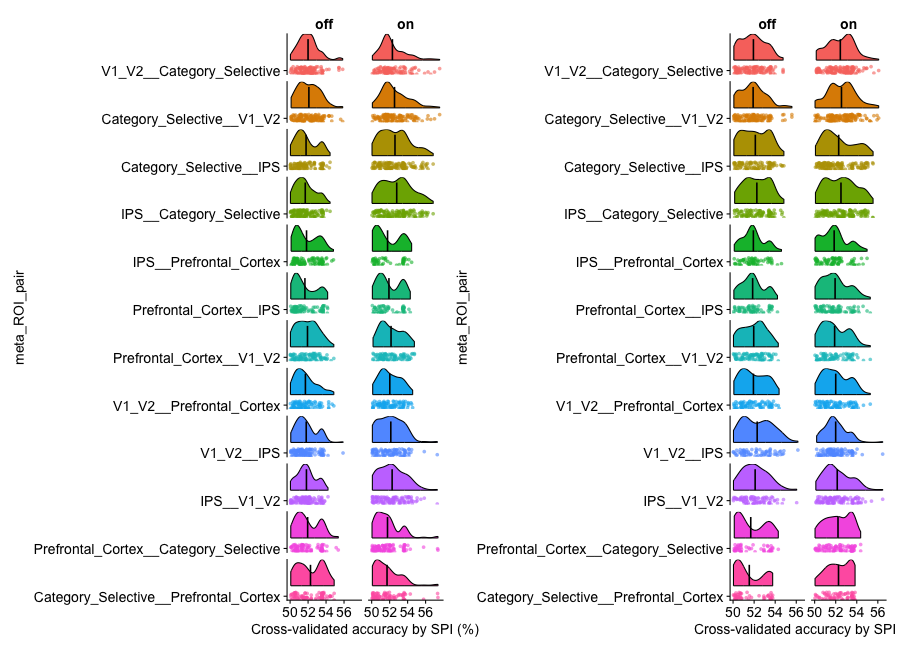

In [43]:
%%R -i cross_task_LR_classification_res,plot_dir -w 900 -h 650 

rel_to_irrel_plot <- cross_task_LR_classification_res %>% 
    filter(cross_task_direction == "relevant_to_irrelevant") %>%
    group_by(SPI, meta_ROI_from, meta_ROI_to, meta_ROI_pair, stimulus_presentation) %>%
    summarise(accuracy = mean(accuracy)) %>%
    # Filter accuracy to >50% for visualization purposes
    filter(accuracy > 0.5) %>%
    mutate(accuracy = 100*accuracy) %>%
    rowwise() %>%
    # Want a specific order for the meta-ROI pair in the plot
    mutate(meta_ROI_pair = factor(meta_ROI_pair, levels = c("V1_V2__Category_Selective",
                                                    "Category_Selective__V1_V2",
                                                    "Category_Selective__IPS",
                                                    "IPS__Category_Selective",
                                                    "IPS__Prefrontal_Cortex",
                                                    "Prefrontal_Cortex__IPS",
                                                    "Prefrontal_Cortex__V1_V2",
                                                    "V1_V2__Prefrontal_Cortex",
                                                    "V1_V2__IPS",
                                                    "IPS__V1_V2",
                                                    "Prefrontal_Cortex__Category_Selective",
                                                    "Category_Selective__Prefrontal_Cortex"))) %>%
    ggplot(data=., mapping=aes(x=meta_ROI_pair, y=accuracy, fill=meta_ROI_pair)) +
    # Create half violins colored by meta-ROI pair and stimulus presentation period
    geom_violinhalf(scale="width", color="black", position = position_nudge(x=0.2), width=1)  +
    geom_point(aes(color = meta_ROI_pair), position = position_jitter(width = 0.075, height=0),
                            size = 1.75, alpha=0.6, stroke=0) +
    stat_summary(color="black", fun="mean", geom="crossbar", width=0.4, linewidth=0.3, 
            show.legend=FALSE, position = position_nudge(x=0.4)) +
    facet_grid(meta_ROI_pair ~ stimulus_presentation, scales="free_y", switch="y") + 
    theme(legend.position = "bottom") +
    scale_x_discrete(expand = c(0, 0)) +
    ylab("Cross-validated accuracy by SPI (%)") +
    labs(fill="Stimulus Presentation", color="Stimulus Presentation") +
    theme(strip.background = element_blank(),
        strip.placement="outside",
        legend.position="none",
        panel.spacing = unit(0.5, "lines"),
        strip.text.y = element_blank(),
        strip.text.x = element_text(size=14, face="bold"),
        axis.text = element_text(size=14)) +
    coord_flip()


irrel_to_rel_plot <- cross_task_LR_classification_res %>% 
    filter(cross_task_direction == "irrelevant_to_relevant") %>%
    group_by(SPI, meta_ROI_from, meta_ROI_to, meta_ROI_pair, stimulus_presentation) %>%
    summarise(accuracy = mean(accuracy)) %>%
    # Filter accuracy to >50% for visualization purposes
    filter(accuracy > 0.5) %>%
    mutate(accuracy = 100*accuracy) %>%
    rowwise() %>%
    # Want a specific order for the meta-ROI pair in the plot
    mutate(meta_ROI_pair = factor(meta_ROI_pair, levels = c("V1_V2__Category_Selective",
                                                    "Category_Selective__V1_V2",
                                                    "Category_Selective__IPS",
                                                    "IPS__Category_Selective",
                                                    "IPS__Prefrontal_Cortex",
                                                    "Prefrontal_Cortex__IPS",
                                                    "Prefrontal_Cortex__V1_V2",
                                                    "V1_V2__Prefrontal_Cortex",
                                                    "V1_V2__IPS",
                                                    "IPS__V1_V2",
                                                    "Prefrontal_Cortex__Category_Selective",
                                                    "Category_Selective__Prefrontal_Cortex"))) %>%
    ggplot(data=., mapping=aes(x=meta_ROI_pair, y=accuracy, fill=meta_ROI_pair)) +
    # Create half violins colored by meta-ROI pair and stimulus presentation period
    geom_violinhalf(scale="width", color="black", position = position_nudge(x=0.2), width=1)  +
    geom_point(aes(color = meta_ROI_pair), position = position_jitter(width = 0.075, height=0),
                            size = 1.75, alpha=0.6, stroke=0) +
    stat_summary(color="black", fun="mean", geom="crossbar", width=0.4, linewidth=0.3, 
            show.legend=FALSE, position = position_nudge(x=0.4)) +
    facet_grid(meta_ROI_pair ~ stimulus_presentation, scales="free_y", switch="y") + 
    theme(legend.position = "bottom") +
    scale_x_discrete(expand = c(0, 0)) +
    ylab("Cross-validated accuracy by SPI (%)") +
    labs(fill="Stimulus Presentation", color="Stimulus Presentation") +
    theme(strip.background = element_blank(),
        strip.placement="outside",
        legend.position="none",
        panel.spacing = unit(0.5, "lines"),
        strip.text.y = element_blank(),
        strip.text.x = element_text(size=14, face="bold"),
        axis.text = element_text(size=14)) +
    coord_flip()

wrap_plots(plotlist = list(rel_to_irrel_plot, irrel_to_rel_plot), ncol = 2)

# ggsave(glue('{plot_dir}/inter_subject_classification/Relevance_type_classification_performance_by_meta_ROI_pair.svg'), width=8, height=8, units='in', dpi=300)